#### workflow
1. Split once: 80/20
2. On the 80 only:
   - run Scanpy
   - create several candidate subsets
   - run CV for each subset
   - choose best subset based on CV mean AUROC
3. Refit best model on all 80 training samples
4. Evaluate once on held-out 20

### imports

In [1]:
# === Imports ===
import os
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import matplotlib.pyplot as plt

from kneed import KneeLocator

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix
)

### 80/20 split 

In [2]:
# === Step 1: Load data and perform 80/20 split ===

# ---- Configuration ----
DATA_PATH = "/mnt/efs/home/ubuntu/M_smartsva_corrected_with_SH_annot_filtered.h5ad"
TARGET_COL = "endo"   # 0 = control, 1 = case
TEST_SIZE = 0.2
RANDOM_STATE = 42

# ---- Load data ----
adata = sc.read_h5ad(DATA_PATH)

print("Full dataset shape:", adata.shape)
print("Available columns in obs:", adata.obs.columns.tolist())

# ---- Basic cleaning ----
if TARGET_COL not in adata.obs.columns:
    raise ValueError(f"{TARGET_COL} not found in adata.obs")

adata = adata[~adata.obs[TARGET_COL].isna(), :].copy()
adata.obs[TARGET_COL] = pd.to_numeric(adata.obs[TARGET_COL], errors="raise").astype(int)

# ---- Extract labels ----
y_full = adata.obs[TARGET_COL].to_numpy()

# ---- 80/20 stratified split ----
train_idx, test_idx = train_test_split(
    np.arange(adata.n_obs),
    test_size=TEST_SIZE,
    stratify=y_full,
    random_state=RANDOM_STATE
)

adata_train = adata[train_idx, :].copy()
adata_test  = adata[test_idx, :].copy()

y_train = adata_train.obs[TARGET_COL].to_numpy()
y_test  = adata_test.obs[TARGET_COL].to_numpy()

# ---- Print summary ----
print("\nTrain shape:", adata_train.shape)
print("Test shape:", adata_test.shape)

print("\nTrain class distribution:")
print(pd.Series(y_train).value_counts().sort_index())
print(pd.Series(y_train).value_counts(normalize=True).sort_index())

print("\nTest class distribution:")
print(pd.Series(y_test).value_counts().sort_index())
print(pd.Series(y_test).value_counts(normalize=True).sort_index())

Full dataset shape: (984, 759345)
Available columns in obs: ['sample-id', 'endo', 'endo-stage', 'endo-stage-grouped', 'cycle-phase', 'cycle-phase-source']

Train shape: (787, 759345)
Test shape: (197, 759345)

Train class distribution:
0    278
1    509
Name: count, dtype: int64
0    0.35324
1    0.64676
Name: proportion, dtype: float64

Test class distribution:
0     69
1    128
Name: count, dtype: int64
0    0.350254
1    0.649746
Name: proportion, dtype: float64


### Run Scanpy selection on the 80% only

In [3]:
# === Step 2: Run Scanpy variability scoring on training set only ===

adata_train_hvg = adata_train.copy()

sc.pp.highly_variable_genes(
    adata_train_hvg,
    flavor="seurat",
    n_top_genes=None,
    subset=False,
    inplace=True
)

if "dispersions_norm" not in adata_train_hvg.var.columns:
    raise ValueError("Scanpy did not create 'dispersions_norm' in adata_train_hvg.var")

print("Columns added to .var:")
print(adata_train_hvg.var.columns.tolist())
print("Number of CpGs:", adata_train_hvg.n_vars)

/home/ubuntu/.local/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:336: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)


Columns added to .var:
['highly_variable', 'means', 'dispersions', 'dispersions_norm']
Number of CpGs: 759345


### extract variability scores from training set

In [4]:
# Build table of CpGs and their variability scores
var_df = pd.DataFrame({
    "cpg_id": adata_train_hvg.var_names,
    "variability_score": adata_train_hvg.var["dispersions_norm"].values
})

# Clean and sort
var_df = var_df.replace([np.inf, -np.inf], np.nan).dropna()
var_df = var_df.sort_values("variability_score", ascending=False).reset_index(drop=True)

print("Total CpGs ranked:", len(var_df))
display(var_df.head(10))

Total CpGs ranked: 480475


,cpg_id,variability_score
0,cg26052187,11.509411
1,cg16454495,9.524692
2,cg23990273,9.461610
3,cg13120260,9.412519
4,cg04517903,9.402356
5,cg14322166,9.316614
6,cg25601889,9.315760
7,cg11344566,9.232896
8,cg15809352,9.186440
9,cg13808936,9.179111


### plot elbow of variability scores and determine cutoff

#### the below workflow will be a plot of the entirety of the features, then we find the elbow, then subset the features to the length of the elbow found, and then train and test a model on that subsetted dataset, and finally, run that model on the held-out 20% data

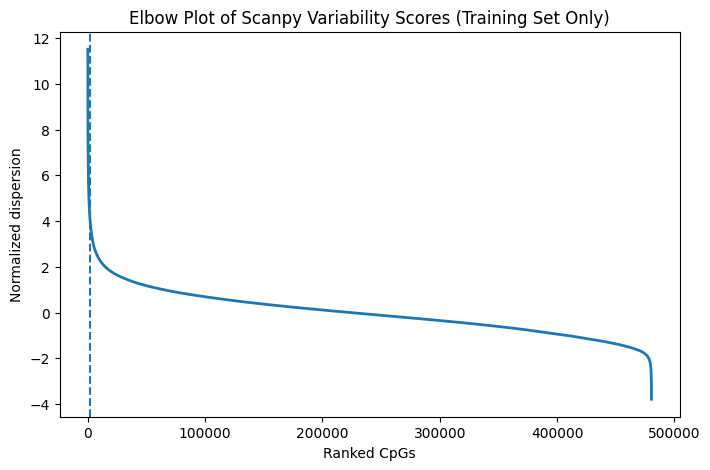

Elbow index: 1770
Top CpGs selected by elbow: 1770


In [5]:
# === Step 4: Elbow plot using training-set variability scores ===

x = np.arange(1, len(var_df) + 1)
y = var_df["variability_score"].to_numpy()

kneedle = KneeLocator(
    x,
    y,
    curve="convex",
    direction="decreasing"
)

knee_idx_full = kneedle.knee

plt.figure(figsize=(8, 5))
plt.plot(x, y, linewidth=2)
if knee_idx_full is not None:
    plt.axvline(knee_idx_full, linestyle="--")
plt.xlabel("Ranked CpGs")
plt.ylabel("Normalized dispersion")
plt.title("Elbow Plot of Scanpy Variability Scores (Training Set Only)")
plt.show()

if knee_idx_full is None:
    raise ValueError("No elbow was detected. Try inspecting the curve or choosing a manual cutoff.")

print("Elbow index:", knee_idx_full)
print("Top CpGs selected by elbow:", knee_idx_full)

In [6]:
# === Step 5: Subset data to elbow-selected CpGs from full training-set ranking ===

top_cpgs_full_elbow = var_df["cpg_id"].iloc[:knee_idx_full].tolist()

adata_train_full_elbow = adata_train[:, top_cpgs_full_elbow].copy()
adata_test_full_elbow  = adata_test[:, top_cpgs_full_elbow].copy()

X_train_full_elbow = adata_train_full_elbow.X
X_test_full_elbow  = adata_test_full_elbow.X

print("Train shape:", X_train_full_elbow.shape)
print("Test shape:", X_test_full_elbow.shape)
print("Number of CpGs used:", len(top_cpgs_full_elbow))

Train shape: (787, 1770)
Test shape: (197, 1770)
Number of CpGs used: 1770


In [7]:
# === Step 6: Train ridge logistic regression on full-elbow feature set ===

Cs = np.logspace(-6, 2, 25)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results_full_elbow = []

for C in Cs:
    pipe = Pipeline([
        ("scaler", StandardScaler(with_mean=not sp.issparse(X_train_full_elbow))),
        ("clf", LogisticRegression(
            penalty="l2",
            C=C,
            solver="lbfgs",
            max_iter=5000,
            random_state=42
        ))
    ])

    cv_aucs = []

    for train_fold_idx, val_fold_idx in cv.split(X_train_full_elbow, y_train):
        X_tr = X_train_full_elbow[train_fold_idx]
        X_val = X_train_full_elbow[val_fold_idx]
        y_tr = y_train[train_fold_idx]
        y_val = y_train[val_fold_idx]

        pipe.fit(X_tr, y_tr)
        y_val_prob = pipe.predict_proba(X_val)[:, 1]
        cv_aucs.append(roc_auc_score(y_val, y_val_prob))

    cv_auc_mean = np.mean(cv_aucs)
    cv_auc_std = np.std(cv_aucs)

    # Refit on full training set
    pipe.fit(X_train_full_elbow, y_train)

    y_train_prob = pipe.predict_proba(X_train_full_elbow)[:, 1]
    y_test_prob = pipe.predict_proba(X_test_full_elbow)[:, 1]

    results_full_elbow.append({
        "C": C,
        "cv_auc_mean": cv_auc_mean,
        "cv_auc_std": cv_auc_std,
        "train_auc": roc_auc_score(y_train, y_train_prob),
        "test_auc": roc_auc_score(y_test, y_test_prob),
        "test_auprc": average_precision_score(y_test, y_test_prob),
        "model": pipe
    })

results_df_full_elbow = pd.DataFrame(results_full_elbow).sort_values(
    "cv_auc_mean", ascending=False
).reset_index(drop=True)

display(results_df_full_elbow[["C", "cv_auc_mean", "cv_auc_std", "train_auc", "test_auc", "test_auprc"]].head(10))

,C,cv_auc_mean,cv_auc_std,train_auc,test_auc,test_auprc
0,2.154435,0.642383,0.020413,1.0,0.662704,0.738913
1,1.000000,0.642096,0.020968,1.0,0.671535,0.742058
2,4.641589,0.640081,0.021646,1.0,0.651495,0.734900
3,0.464159,0.639445,0.020327,1.0,0.672554,0.741502
4,10.000000,0.637255,0.023003,1.0,0.651721,0.737647
5,0.215443,0.637044,0.020993,1.0,0.673573,0.740853
6,46.415888,0.636718,0.027865,1.0,0.653419,0.739835
7,21.544347,0.636390,0.025628,1.0,0.654778,0.741310
8,100.000000,0.636097,0.028584,1.0,0.652966,0.739129
9,0.100000,0.634119,0.020840,1.0,0.672441,0.739449


Best C: 2.154434690031882
Best CV mean AUROC: 0.6423825722908425
Held-out test AUROC: 0.662703804347826


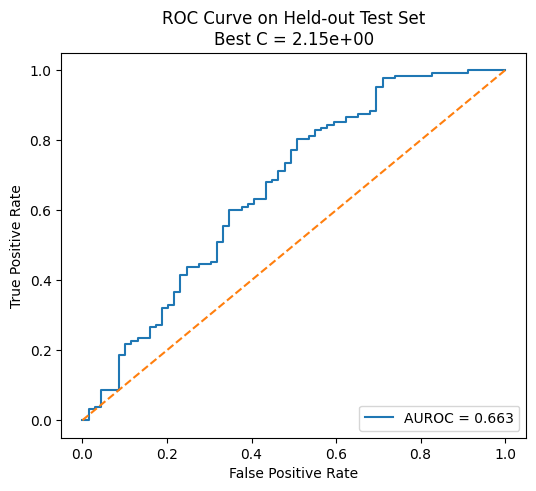

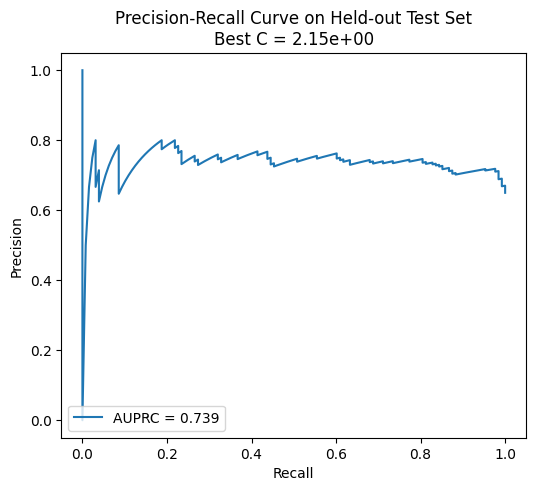

In [8]:
# === Step 7: Plot ROC and PR curves for best full-elbow model ===

best_row_full_elbow = results_df_full_elbow.iloc[0]
best_C_full_elbow = best_row_full_elbow["C"]
best_model_full_elbow = best_row_full_elbow["model"]

print("Best C:", best_C_full_elbow)
print("Best CV mean AUROC:", best_row_full_elbow["cv_auc_mean"])
print("Held-out test AUROC:", best_row_full_elbow["test_auc"])

# Predict probabilities on held-out test set
y_test_prob_full_elbow = best_model_full_elbow.predict_proba(X_test_full_elbow)[:, 1]

# ---- ROC curve ----
fpr, tpr, _ = roc_curve(y_test, y_test_prob_full_elbow)
test_auroc = roc_auc_score(y_test, y_test_prob_full_elbow)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUROC = {test_auroc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve on Held-out Test Set\nBest C = {best_C_full_elbow:.2e}")
plt.legend(loc="lower right")
plt.show()

# ---- PR curve ----
precision, recall, _ = precision_recall_curve(y_test, y_test_prob_full_elbow)
test_auprc = average_precision_score(y_test, y_test_prob_full_elbow)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"AUPRC = {test_auprc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve on Held-out Test Set\nBest C = {best_C_full_elbow:.2e}")
plt.legend(loc="lower left")
plt.show()

In [9]:
# === Step 8: Save full-elbow results ===

out_dir = "scanpy_hvg_results"
os.makedirs(out_dir, exist_ok=True)

results_df_full_elbow.to_csv(
    os.path.join(out_dir, "results_full_elbow.csv"),
    index=False
)

pd.DataFrame({
    "cpg_id": top_cpgs_full_elbow
}).to_csv(
    os.path.join(out_dir, "top_cpgs_full_elbow.csv"),
    index=False
)

print("Saved:")
print(os.path.join(out_dir, "results_full_elbow.csv"))
print(os.path.join(out_dir, "top_cpgs_full_elbow.csv"))

Saved:
scanpy_hvg_results/results_full_elbow.csv
scanpy_hvg_results/top_cpgs_full_elbow.csv


#### the below workflow will be a plot of the top 10000 features, then we find the elbow, then subset the features to the length of the elbow found, and then train and test a model on that subsetted dataset, and finally, run that model on the held-out 20% data

In [10]:
# === Step 9: Select top 10,000 CpGs by variability ===

TOP_K = 10000

if len(var_df) < TOP_K:
    raise ValueError(f"var_df has only {len(var_df)} rows, which is fewer than TOP_K={TOP_K}")

var_df_10k = var_df.iloc[:TOP_K].copy()

print("Using top", len(var_df_10k), "CpGs for elbow analysis")
display(var_df_10k.head())

Using top 10000 CpGs for elbow analysis


,cpg_id,variability_score
0,cg26052187,11.509411
1,cg16454495,9.524692
2,cg23990273,9.461610
3,cg13120260,9.412519
4,cg04517903,9.402356


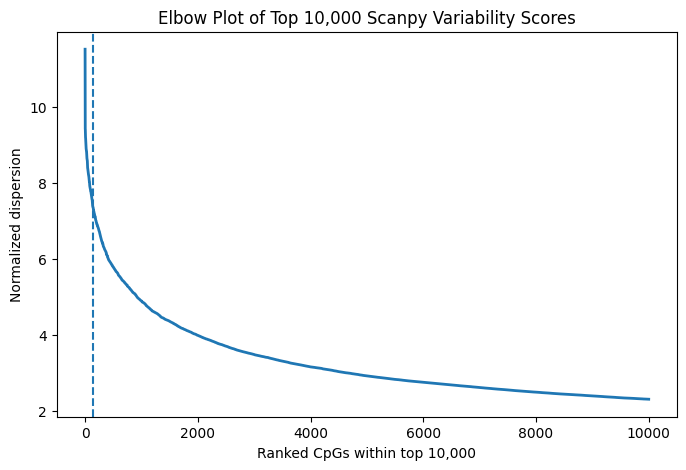

Elbow index within top 10,000: 149
Top CpGs selected by elbow from 10,000 subset: 149


In [11]:
# === Step 10: Elbow plot for top 10,000 CpGs ===

x_10k = np.arange(1, len(var_df_10k) + 1)
y_10k = var_df_10k["variability_score"].to_numpy()

kneedle_10k = KneeLocator(
    x_10k,
    y_10k,
    curve="convex",
    direction="decreasing"
)

knee_idx_10k = kneedle_10k.knee

plt.figure(figsize=(8, 5))
plt.plot(x_10k, y_10k, linewidth=2)
if knee_idx_10k is not None:
    plt.axvline(knee_idx_10k, linestyle="--")
plt.xlabel("Ranked CpGs within top 10,000")
plt.ylabel("Normalized dispersion")
plt.title("Elbow Plot of Top 10,000 Scanpy Variability Scores")
plt.show()

if knee_idx_10k is None:
    raise ValueError("No elbow detected for the top 10,000 subset.")

print("Elbow index within top 10,000:", knee_idx_10k)
print("Top CpGs selected by elbow from 10,000 subset:", knee_idx_10k)

In [12]:
# === Step 11: Subset data to top-10k-elbow-selected CpGs ===

top_cpgs_10k_elbow = var_df_10k["cpg_id"].iloc[:knee_idx_10k].tolist()

adata_train_10k_elbow = adata_train[:, top_cpgs_10k_elbow].copy()
adata_test_10k_elbow  = adata_test[:, top_cpgs_10k_elbow].copy()

X_train_10k_elbow = adata_train_10k_elbow.X
X_test_10k_elbow  = adata_test_10k_elbow.X

print("Train shape:", X_train_10k_elbow.shape)
print("Test shape:", X_test_10k_elbow.shape)
print("Number of CpGs used:", len(top_cpgs_10k_elbow))

Train shape: (787, 149)
Test shape: (197, 149)
Number of CpGs used: 149


In [13]:
# === Step 12: Train ridge logistic regression on top-10k-elbow feature set ===

Cs = np.logspace(-6, 2, 25)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results_10k_elbow = []

for C in Cs:
    pipe = Pipeline([
        ("scaler", StandardScaler(with_mean=not sp.issparse(X_train_10k_elbow))),
        ("clf", LogisticRegression(
            penalty="l2",
            C=C,
            solver="lbfgs",
            max_iter=5000,
            random_state=42
        ))
    ])

    cv_aucs = []

    for train_fold_idx, val_fold_idx in cv.split(X_train_10k_elbow, y_train):
        X_tr = X_train_10k_elbow[train_fold_idx]
        X_val = X_train_10k_elbow[val_fold_idx]
        y_tr = y_train[train_fold_idx]
        y_val = y_train[val_fold_idx]

        pipe.fit(X_tr, y_tr)
        y_val_prob = pipe.predict_proba(X_val)[:, 1]
        cv_aucs.append(roc_auc_score(y_val, y_val_prob))

    cv_auc_mean = np.mean(cv_aucs)
    cv_auc_std = np.std(cv_aucs)

    # Refit on the full 80% training set
    pipe.fit(X_train_10k_elbow, y_train)

    y_train_prob = pipe.predict_proba(X_train_10k_elbow)[:, 1]
    y_test_prob = pipe.predict_proba(X_test_10k_elbow)[:, 1]

    results_10k_elbow.append({
        "C": C,
        "cv_auc_mean": cv_auc_mean,
        "cv_auc_std": cv_auc_std,
        "train_auc": roc_auc_score(y_train, y_train_prob),
        "test_auc": roc_auc_score(y_test, y_test_prob),
        "test_auprc": average_precision_score(y_test, y_test_prob),
        "model": pipe
    })

results_df_10k_elbow = pd.DataFrame(results_10k_elbow).sort_values(
    "cv_auc_mean", ascending=False
).reset_index(drop=True)

display(results_df_10k_elbow[["C", "cv_auc_mean", "cv_auc_std", "train_auc", "test_auc", "test_auprc"]].head(10))

,C,cv_auc_mean,cv_auc_std,train_auc,test_auc,test_auprc
0,0.000464,0.564033,0.017292,0.733919,0.560122,0.706550
1,0.001000,0.563534,0.018067,0.741820,0.558650,0.704188
2,0.002154,0.562291,0.016587,0.751735,0.558990,0.703957
3,0.000215,0.561810,0.017406,0.728718,0.557178,0.705352
4,0.000100,0.559950,0.018192,0.724958,0.555933,0.705050
5,0.004642,0.559758,0.017722,0.762138,0.556612,0.700975
6,0.021544,0.559361,0.020159,0.780159,0.557405,0.702595
7,0.010000,0.559001,0.019242,0.772236,0.555367,0.699934
8,0.000046,0.558681,0.018566,0.722647,0.555820,0.704504
9,0.000001,0.558362,0.018845,0.720082,0.555254,0.704611


Best C: 0.00046415888336127773
Best CV mean AUROC: 0.5640332856815093
Held-out test AUROC: 0.5601222826086958


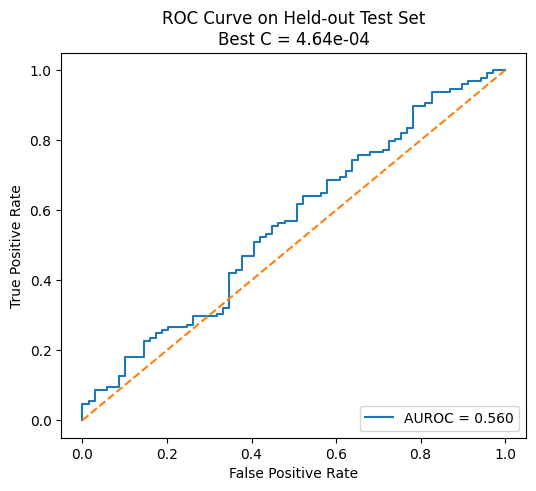

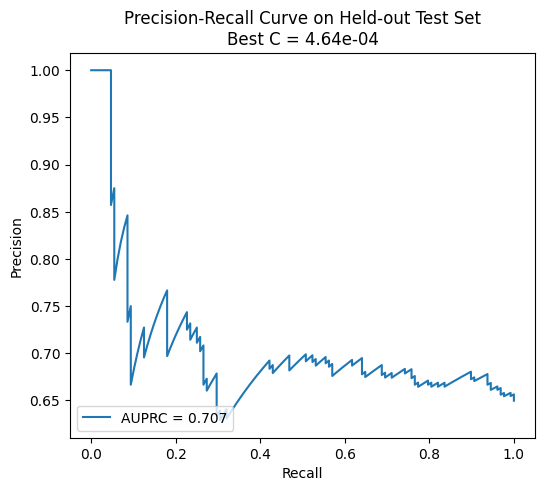

In [14]:
# === Step 13: Plot ROC and PR curves for best top-10k-elbow model ===

best_row_10k_elbow = results_df_10k_elbow.iloc[0]
best_C_10k_elbow = best_row_10k_elbow["C"]
best_model_10k_elbow = best_row_10k_elbow["model"]

print("Best C:", best_C_10k_elbow)
print("Best CV mean AUROC:", best_row_10k_elbow["cv_auc_mean"])
print("Held-out test AUROC:", best_row_10k_elbow["test_auc"])

# Predict probabilities on held-out test set
y_test_prob_10k_elbow = best_model_10k_elbow.predict_proba(X_test_10k_elbow)[:, 1]

# ---- ROC curve ----
fpr, tpr, _ = roc_curve(y_test, y_test_prob_10k_elbow)
test_auroc = roc_auc_score(y_test, y_test_prob_10k_elbow)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUROC = {test_auroc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve on Held-out Test Set\nBest C = {best_C_10k_elbow:.2e}")
plt.legend(loc="lower right")
plt.show()

# ---- PR curve ----
precision, recall, _ = precision_recall_curve(y_test, y_test_prob_10k_elbow)
test_auprc = average_precision_score(y_test, y_test_prob_10k_elbow)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"AUPRC = {test_auprc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve on Held-out Test Set\nBest C = {best_C_10k_elbow:.2e}")
plt.legend(loc="lower left")
plt.show()

In [15]:
# === Step 14: Save top-10k-elbow results ===

out_dir = "scanpy_hvg_results"
os.makedirs(out_dir, exist_ok=True)

results_df_10k_elbow.to_csv(
    os.path.join(out_dir, "results_10k_elbow.csv"),
    index=False
)

pd.DataFrame({
    "cpg_id": top_cpgs_10k_elbow
}).to_csv(
    os.path.join(out_dir, "top_cpgs_10k_elbow.csv"),
    index=False
)

print("Saved:")
print(os.path.join(out_dir, "results_10k_elbow.csv"))
print(os.path.join(out_dir, "top_cpgs_10k_elbow.csv"))

Saved:
scanpy_hvg_results/results_10k_elbow.csv
scanpy_hvg_results/top_cpgs_10k_elbow.csv


#### the below workflow will be a plot of the top 20000 features, then we find the elbow, then subset the features to the length of the elbow found, and then train and test a model on that subsetted dataset, and finally, run that model on the held-out 20% data

In [16]:
# === Step 15: Select top 20,000 CpGs by variability ===

TOP_K = 20000

if len(var_df) < TOP_K:
    raise ValueError(f"var_df has only {len(var_df)} rows, which is fewer than TOP_K={TOP_K}")

var_df_20k = var_df.iloc[:TOP_K].copy()

print("Using top", len(var_df_20k), "CpGs for elbow analysis")
display(var_df_20k.head())

Using top 20000 CpGs for elbow analysis


,cpg_id,variability_score
0,cg26052187,11.509411
1,cg16454495,9.524692
2,cg23990273,9.461610
3,cg13120260,9.412519
4,cg04517903,9.402356


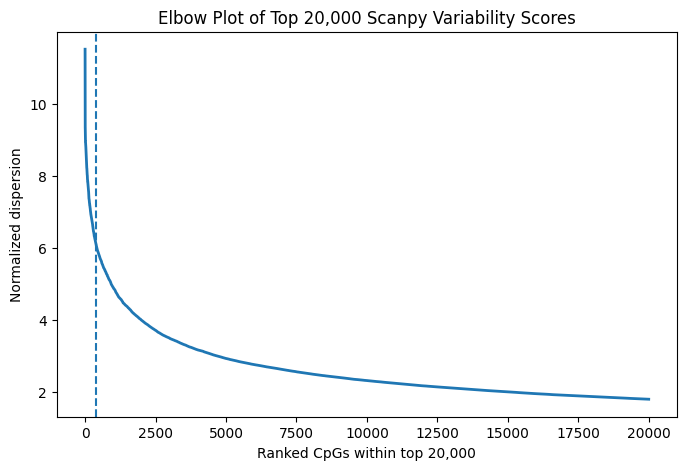

Elbow index within top 20,000: 387
Top CpGs selected by elbow from 20,000 subset: 387


In [17]:
# === Step 16: Elbow plot for top 20,000 CpGs ===

x_20k = np.arange(1, len(var_df_20k) + 1)
y_20k = var_df_20k["variability_score"].to_numpy()

kneedle_20k = KneeLocator(
    x_20k,
    y_20k,
    curve="convex",
    direction="decreasing"
)

knee_idx_20k = kneedle_20k.knee

plt.figure(figsize=(8, 5))
plt.plot(x_20k, y_20k, linewidth=2)
if knee_idx_20k is not None:
    plt.axvline(knee_idx_20k, linestyle="--")
plt.xlabel("Ranked CpGs within top 20,000")
plt.ylabel("Normalized dispersion")
plt.title("Elbow Plot of Top 20,000 Scanpy Variability Scores")
plt.show()

if knee_idx_20k is None:
    raise ValueError("No elbow detected for the top 20,000 subset.")

print("Elbow index within top 20,000:", knee_idx_20k)
print("Top CpGs selected by elbow from 20,000 subset:", knee_idx_20k)

In [18]:
# === Step 17: Subset data to top-20k-elbow-selected CpGs ===

top_cpgs_20k_elbow = var_df_20k["cpg_id"].iloc[:knee_idx_20k].tolist()

adata_train_20k_elbow = adata_train[:, top_cpgs_20k_elbow].copy()
adata_test_20k_elbow  = adata_test[:, top_cpgs_20k_elbow].copy()

X_train_20k_elbow = adata_train_20k_elbow.X
X_test_20k_elbow  = adata_test_20k_elbow.X

print("Train shape:", X_train_20k_elbow.shape)
print("Test shape:", X_test_20k_elbow.shape)
print("Number of CpGs used:", len(top_cpgs_20k_elbow))

Train shape: (787, 387)
Test shape: (197, 387)
Number of CpGs used: 387


In [19]:
# === Step 18: Train ridge logistic regression on top-20k-elbow feature set ===

Cs = np.logspace(-6, 2, 25)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results_20k_elbow = []

for C in Cs:
    pipe = Pipeline([
        ("scaler", StandardScaler(with_mean=not sp.issparse(X_train_20k_elbow))),
        ("clf", LogisticRegression(
            penalty="l2",
            C=C,
            solver="lbfgs",
            max_iter=5000,
            random_state=42
        ))
    ])

    cv_aucs = []

    for train_fold_idx, val_fold_idx in cv.split(X_train_20k_elbow, y_train):
        X_tr = X_train_20k_elbow[train_fold_idx]
        X_val = X_train_20k_elbow[val_fold_idx]
        y_tr = y_train[train_fold_idx]
        y_val = y_train[val_fold_idx]

        pipe.fit(X_tr, y_tr)
        y_val_prob = pipe.predict_proba(X_val)[:, 1]
        cv_aucs.append(roc_auc_score(y_val, y_val_prob))

    cv_auc_mean = np.mean(cv_aucs)
    cv_auc_std = np.std(cv_aucs)

    # Refit on the full 80% training set
    pipe.fit(X_train_20k_elbow, y_train)

    y_train_prob = pipe.predict_proba(X_train_20k_elbow)[:, 1]
    y_test_prob = pipe.predict_proba(X_test_20k_elbow)[:, 1]

    results_20k_elbow.append({
        "C": C,
        "cv_auc_mean": cv_auc_mean,
        "cv_auc_std": cv_auc_std,
        "train_auc": roc_auc_score(y_train, y_train_prob),
        "test_auc": roc_auc_score(y_test, y_test_prob),
        "test_auprc": average_precision_score(y_test, y_test_prob),
        "model": pipe
    })

results_df_20k_elbow = pd.DataFrame(results_20k_elbow).sort_values(
    "cv_auc_mean", ascending=False
).reset_index(drop=True)

display(results_df_20k_elbow[["C", "cv_auc_mean", "cv_auc_std", "train_auc", "test_auc", "test_auprc"]].head(10))

,C,cv_auc_mean,cv_auc_std,train_auc,test_auc,test_auprc
0,0.000464,0.561526,0.043085,0.848511,0.580503,0.685390
1,0.001000,0.561020,0.040876,0.860680,0.578578,0.682364
2,0.002154,0.560584,0.037577,0.875981,0.578238,0.682527
3,0.000215,0.560158,0.042535,0.840334,0.583560,0.688507
4,0.000022,0.557400,0.041738,0.832250,0.582428,0.687199
5,0.000046,0.557299,0.041984,0.833501,0.582428,0.686998
6,0.000100,0.557085,0.042581,0.836059,0.583107,0.689628
7,0.000010,0.557083,0.041279,0.831628,0.582314,0.687064
8,0.000005,0.556800,0.041341,0.831486,0.582201,0.687126
9,0.000002,0.556765,0.041023,0.831183,0.582767,0.687447


Best C: 0.00046415888336127773
Best CV mean AUROC: 0.5615264026402641
Held-out test AUROC: 0.5805027173913043


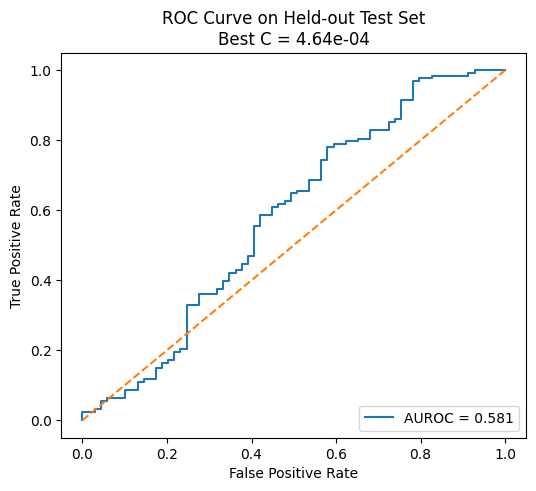

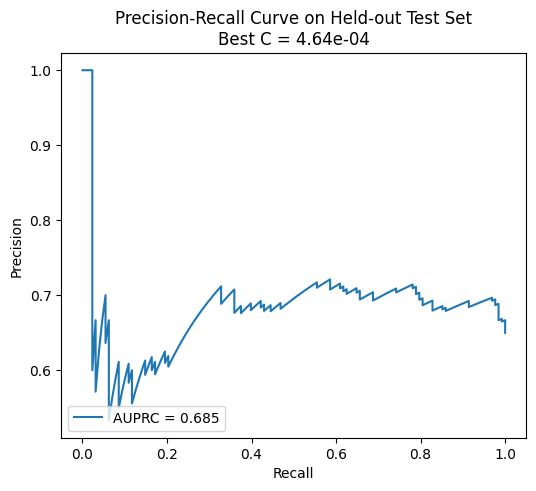

In [20]:
# === Step 19: Plot ROC and PR curves for best top-20k-elbow model ===

best_row_20k_elbow = results_df_20k_elbow.iloc[0]
best_C_20k_elbow = best_row_20k_elbow["C"]
best_model_20k_elbow = best_row_20k_elbow["model"]

print("Best C:", best_C_20k_elbow)
print("Best CV mean AUROC:", best_row_20k_elbow["cv_auc_mean"])
print("Held-out test AUROC:", best_row_20k_elbow["test_auc"])

# Predict probabilities on held-out test set
y_test_prob_20k_elbow = best_model_20k_elbow.predict_proba(X_test_20k_elbow)[:, 1]

# ---- ROC curve ----
fpr, tpr, _ = roc_curve(y_test, y_test_prob_20k_elbow)
test_auroc = roc_auc_score(y_test, y_test_prob_20k_elbow)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUROC = {test_auroc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve on Held-out Test Set\nBest C = {best_C_20k_elbow:.2e}")
plt.legend(loc="lower right")
plt.show()

# ---- PR curve ----
precision, recall, _ = precision_recall_curve(y_test, y_test_prob_20k_elbow)
test_auprc = average_precision_score(y_test, y_test_prob_20k_elbow)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"AUPRC = {test_auprc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve on Held-out Test Set\nBest C = {best_C_20k_elbow:.2e}")
plt.legend(loc="lower left")
plt.show()

In [21]:
# === Step 20: Save top-20k-elbow results ===

out_dir = "scanpy_hvg_results"
os.makedirs(out_dir, exist_ok=True)

results_df_20k_elbow.to_csv(
    os.path.join(out_dir, "results_20k_elbow.csv"),
    index=False
)

pd.DataFrame({
    "cpg_id": top_cpgs_20k_elbow
}).to_csv(
    os.path.join(out_dir, "top_cpgs_20k_elbow.csv"),
    index=False
)

print("Saved:")
print(os.path.join(out_dir, "results_20k_elbow.csv"))
print(os.path.join(out_dir, "top_cpgs_20k_elbow.csv"))

Saved:
scanpy_hvg_results/results_20k_elbow.csv
scanpy_hvg_results/top_cpgs_20k_elbow.csv


#### the below workflow will be a plot of the top 50000 features, then we find the elbow, then subset the features to the length of the elbow found, and then train and test a model on that subsetted dataset, and finally, run that model on the held-out 20% data

In [22]:
# === Step 21: Select top 50,000 CpGs by variability ===

TOP_K = 50000

if len(var_df) < TOP_K:
    raise ValueError(f"var_df has only {len(var_df)} rows, which is fewer than TOP_K={TOP_K}")

var_df_50k = var_df.iloc[:TOP_K].copy()

print("Using top", len(var_df_50k), "CpGs for elbow analysis")
display(var_df_50k.head())

Using top 50000 CpGs for elbow analysis


,cpg_id,variability_score
0,cg26052187,11.509411
1,cg16454495,9.524692
2,cg23990273,9.461610
3,cg13120260,9.412519
4,cg04517903,9.402356


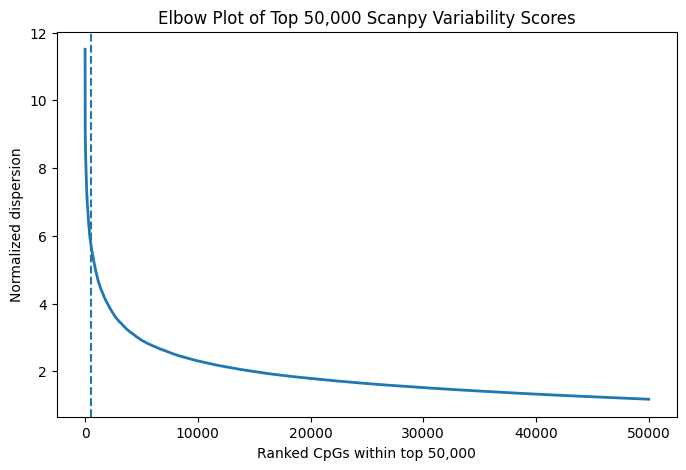

Elbow index within top 50,000: 535
Top CpGs selected by elbow from 50,000 subset: 535


In [23]:
# === Step 22: Elbow plot for top 50,000 CpGs ===

x_50k = np.arange(1, len(var_df_50k) + 1)
y_50k = var_df_50k["variability_score"].to_numpy()

kneedle_50k = KneeLocator(
    x_50k,
    y_50k,
    curve="convex",
    direction="decreasing"
)

knee_idx_50k = kneedle_50k.knee

plt.figure(figsize=(8, 5))
plt.plot(x_50k, y_50k, linewidth=2)
if knee_idx_50k is not None:
    plt.axvline(knee_idx_50k, linestyle="--")
plt.xlabel("Ranked CpGs within top 50,000")
plt.ylabel("Normalized dispersion")
plt.title("Elbow Plot of Top 50,000 Scanpy Variability Scores")
plt.show()

if knee_idx_50k is None:
    raise ValueError("No elbow detected for the top 50,000 subset.")

print("Elbow index within top 50,000:", knee_idx_50k)
print("Top CpGs selected by elbow from 50,000 subset:", knee_idx_50k)

In [24]:
# === Step 23: Subset data to top-50k-elbow-selected CpGs ===

top_cpgs_50k_elbow = var_df_50k["cpg_id"].iloc[:knee_idx_50k].tolist()

adata_train_50k_elbow = adata_train[:, top_cpgs_50k_elbow].copy()
adata_test_50k_elbow  = adata_test[:, top_cpgs_50k_elbow].copy()

X_train_50k_elbow = adata_train_50k_elbow.X
X_test_50k_elbow  = adata_test_50k_elbow.X

print("Train shape:", X_train_50k_elbow.shape)
print("Test shape:", X_test_50k_elbow.shape)
print("Number of CpGs used:", len(top_cpgs_50k_elbow))

Train shape: (787, 535)
Test shape: (197, 535)
Number of CpGs used: 535


In [25]:
# === Step 24: Train ridge logistic regression on top-50k-elbow feature set ===

Cs = np.logspace(-6, 2, 25)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results_50k_elbow = []

for C in Cs:
    pipe = Pipeline([
        ("scaler", StandardScaler(with_mean=not sp.issparse(X_train_50k_elbow))),
        ("clf", LogisticRegression(
            penalty="l2",
            C=C,
            solver="lbfgs",
            max_iter=5000,
            random_state=42
        ))
    ])

    cv_aucs = []

    for train_fold_idx, val_fold_idx in cv.split(X_train_50k_elbow, y_train):
        X_tr = X_train_50k_elbow[train_fold_idx]
        X_val = X_train_50k_elbow[val_fold_idx]
        y_tr = y_train[train_fold_idx]
        y_val = y_train[val_fold_idx]

        pipe.fit(X_tr, y_tr)
        y_val_prob = pipe.predict_proba(X_val)[:, 1]
        cv_aucs.append(roc_auc_score(y_val, y_val_prob))

    cv_auc_mean = np.mean(cv_aucs)
    cv_auc_std = np.std(cv_aucs)

    # Refit on the full 80% training set
    pipe.fit(X_train_50k_elbow, y_train)

    y_train_prob = pipe.predict_proba(X_train_50k_elbow)[:, 1]
    y_test_prob = pipe.predict_proba(X_test_50k_elbow)[:, 1]

    results_50k_elbow.append({
        "C": C,
        "cv_auc_mean": cv_auc_mean,
        "cv_auc_std": cv_auc_std,
        "train_auc": roc_auc_score(y_train, y_train_prob),
        "test_auc": roc_auc_score(y_test, y_test_prob),
        "test_auprc": average_precision_score(y_test, y_test_prob),
        "model": pipe
    })

results_df_50k_elbow = pd.DataFrame(results_50k_elbow).sort_values(
    "cv_auc_mean", ascending=False
).reset_index(drop=True)

display(results_df_50k_elbow[["C", "cv_auc_mean", "cv_auc_std", "train_auc", "test_auc", "test_auprc"]].head(10))

,C,cv_auc_mean,cv_auc_std,train_auc,test_auc,test_auprc
0,0.215443,0.548782,0.020073,0.998841,0.573030,0.672596
1,0.100000,0.548505,0.018796,0.994092,0.569293,0.669282
2,0.000100,0.548157,0.031502,0.866327,0.561594,0.686884
3,0.464159,0.548105,0.021348,0.999951,0.573483,0.676374
4,0.000046,0.547948,0.031101,0.863260,0.560349,0.687695
5,0.000215,0.547829,0.032142,0.872822,0.562613,0.684379
6,0.000022,0.547703,0.030796,0.861733,0.560009,0.687171
7,0.000010,0.547632,0.030822,0.860885,0.560122,0.687234
8,0.000002,0.547600,0.030688,0.860341,0.559669,0.687353
9,0.000001,0.547565,0.030589,0.860271,0.559669,0.687349


Best C: 0.21544346900318823
Best CV mean AUROC: 0.54878197903824
Held-out test AUROC: 0.5730298913043479


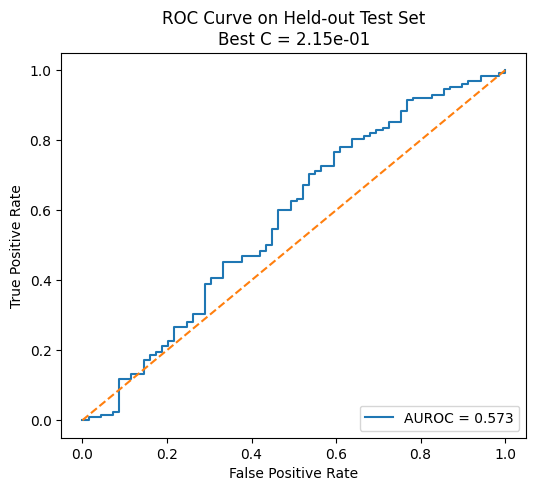

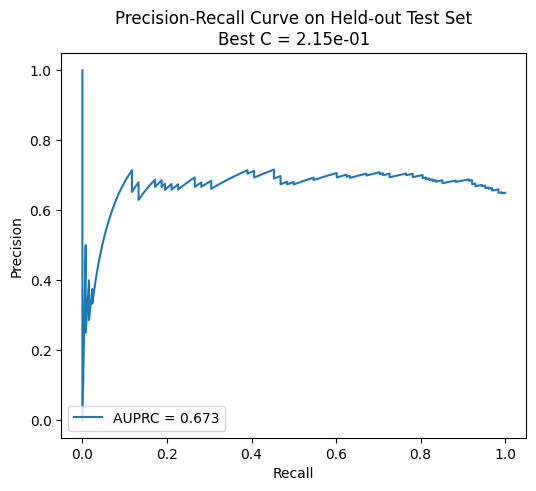

In [26]:
# === Step 25: Plot ROC and PR curves for best top-50k-elbow model ===

best_row_50k_elbow = results_df_50k_elbow.iloc[0]
best_C_50k_elbow = best_row_50k_elbow["C"]
best_model_50k_elbow = best_row_50k_elbow["model"]

print("Best C:", best_C_50k_elbow)
print("Best CV mean AUROC:", best_row_50k_elbow["cv_auc_mean"])
print("Held-out test AUROC:", best_row_50k_elbow["test_auc"])

# Predict probabilities on held-out test set
y_test_prob_50k_elbow = best_model_50k_elbow.predict_proba(X_test_50k_elbow)[:, 1]

# ---- ROC curve ----
fpr, tpr, _ = roc_curve(y_test, y_test_prob_50k_elbow)
test_auroc = roc_auc_score(y_test, y_test_prob_50k_elbow)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUROC = {test_auroc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve on Held-out Test Set\nBest C = {best_C_50k_elbow:.2e}")
plt.legend(loc="lower right")
plt.show()

# ---- PR curve ----
precision, recall, _ = precision_recall_curve(y_test, y_test_prob_50k_elbow)
test_auprc = average_precision_score(y_test, y_test_prob_50k_elbow)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"AUPRC = {test_auprc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve on Held-out Test Set\nBest C = {best_C_50k_elbow:.2e}")
plt.legend(loc="lower left")
plt.show()

In [27]:
# === Step 26: Save top-50k-elbow results ===

out_dir = "scanpy_hvg_results"
os.makedirs(out_dir, exist_ok=True)

results_df_50k_elbow.to_csv(
    os.path.join(out_dir, "results_50k_elbow.csv"),
    index=False
)

pd.DataFrame({
    "cpg_id": top_cpgs_50k_elbow
}).to_csv(
    os.path.join(out_dir, "top_cpgs_50k_elbow.csv"),
    index=False
)

print("Saved:")
print(os.path.join(out_dir, "results_50k_elbow.csv"))
print(os.path.join(out_dir, "top_cpgs_50k_elbow.csv"))

Saved:
scanpy_hvg_results/results_50k_elbow.csv
scanpy_hvg_results/top_cpgs_50k_elbow.csv


#### the below workflow will be a plot of the top 35000 features, then we find the elbow, then subset the features to the length of the elbow found, and then train and test a model on that subsetted dataset, and finally, run that model on the held-out 20% data

In [28]:
# === Step 27: Select top 35,000 CpGs by variability ===

TOP_K = 35000

if len(var_df) < TOP_K:
    raise ValueError(f"var_df has only {len(var_df)} rows, which is fewer than TOP_K={TOP_K}")

var_df_35k = var_df.iloc[:TOP_K].copy()

print("Using top", len(var_df_35k), "CpGs for elbow analysis")
display(var_df_35k.head())

Using top 35000 CpGs for elbow analysis


,cpg_id,variability_score
0,cg26052187,11.509411
1,cg16454495,9.524692
2,cg23990273,9.461610
3,cg13120260,9.412519
4,cg04517903,9.402356


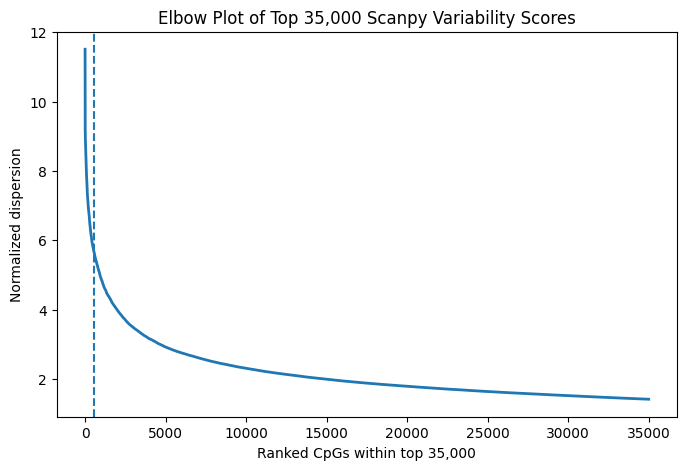

Elbow index within top 35,000: 535
Top CpGs selected by elbow from 35,000 subset: 535


In [29]:
# === Step 28: Elbow plot for top 35,000 CpGs ===

x_35k = np.arange(1, len(var_df_35k) + 1)
y_35k = var_df_35k["variability_score"].to_numpy()

kneedle_35k = KneeLocator(
    x_35k,
    y_35k,
    curve="convex",
    direction="decreasing"
)

knee_idx_35k = kneedle_35k.knee

plt.figure(figsize=(8, 5))
plt.plot(x_35k, y_35k, linewidth=2)
if knee_idx_35k is not None:
    plt.axvline(knee_idx_35k, linestyle="--")
plt.xlabel("Ranked CpGs within top 35,000")
plt.ylabel("Normalized dispersion")
plt.title("Elbow Plot of Top 35,000 Scanpy Variability Scores")
plt.show()

if knee_idx_35k is None:
    raise ValueError("No elbow detected for the top 35,000 subset.")

print("Elbow index within top 35,000:", knee_idx_35k)
print("Top CpGs selected by elbow from 35,000 subset:", knee_idx_35k)

In [30]:
# === Step 29: Subset data to top-35k-elbow-selected CpGs ===

top_cpgs_35k_elbow = var_df_35k["cpg_id"].iloc[:knee_idx_35k].tolist()

adata_train_35k_elbow = adata_train[:, top_cpgs_35k_elbow].copy()
adata_test_35k_elbow  = adata_test[:, top_cpgs_35k_elbow].copy()

X_train_35k_elbow = adata_train_35k_elbow.X
X_test_35k_elbow  = adata_test_35k_elbow.X

print("Train shape:", X_train_35k_elbow.shape)
print("Test shape:", X_test_35k_elbow.shape)
print("Number of CpGs used:", len(top_cpgs_35k_elbow))

Train shape: (787, 535)
Test shape: (197, 535)
Number of CpGs used: 535


In [31]:
# === Step 30: Train ridge logistic regression on top-35k-elbow feature set ===

Cs = np.logspace(-6, 2, 25)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results_35k_elbow = []

for C in Cs:
    pipe = Pipeline([
        ("scaler", StandardScaler(with_mean=not sp.issparse(X_train_35k_elbow))),
        ("clf", LogisticRegression(
            penalty="l2",
            C=C,
            solver="lbfgs",
            max_iter=5000,
            random_state=42
        ))
    ])

    cv_aucs = []

    for train_fold_idx, val_fold_idx in cv.split(X_train_35k_elbow, y_train):
        X_tr = X_train_35k_elbow[train_fold_idx]
        X_val = X_train_35k_elbow[val_fold_idx]
        y_tr = y_train[train_fold_idx]
        y_val = y_train[val_fold_idx]

        pipe.fit(X_tr, y_tr)
        y_val_prob = pipe.predict_proba(X_val)[:, 1]
        cv_aucs.append(roc_auc_score(y_val, y_val_prob))

    cv_auc_mean = np.mean(cv_aucs)
    cv_auc_std = np.std(cv_aucs)

    # Refit on the full 80% training set
    pipe.fit(X_train_35k_elbow, y_train)

    y_train_prob = pipe.predict_proba(X_train_35k_elbow)[:, 1]
    y_test_prob = pipe.predict_proba(X_test_35k_elbow)[:, 1]

    results_35k_elbow.append({
        "C": C,
        "cv_auc_mean": cv_auc_mean,
        "cv_auc_std": cv_auc_std,
        "train_auc": roc_auc_score(y_train, y_train_prob),
        "test_auc": roc_auc_score(y_test, y_test_prob),
        "test_auprc": average_precision_score(y_test, y_test_prob),
        "model": pipe
    })

results_df_35k_elbow = pd.DataFrame(results_35k_elbow).sort_values(
    "cv_auc_mean", ascending=False
).reset_index(drop=True)

display(results_df_35k_elbow[["C", "cv_auc_mean", "cv_auc_std", "train_auc", "test_auc", "test_auprc"]].head(10))

,C,cv_auc_mean,cv_auc_std,train_auc,test_auc,test_auprc
0,0.215443,0.548782,0.020073,0.998841,0.573030,0.672596
1,0.100000,0.548505,0.018796,0.994092,0.569293,0.669282
2,0.000100,0.548157,0.031502,0.866327,0.561594,0.686884
3,0.464159,0.548105,0.021348,0.999951,0.573483,0.676374
4,0.000046,0.547948,0.031101,0.863260,0.560349,0.687695
5,0.000215,0.547829,0.032142,0.872822,0.562613,0.684379
6,0.000022,0.547703,0.030796,0.861733,0.560009,0.687171
7,0.000010,0.547632,0.030822,0.860885,0.560122,0.687234
8,0.000002,0.547600,0.030688,0.860341,0.559669,0.687353
9,0.000001,0.547565,0.030589,0.860271,0.559669,0.687349


Best C: 0.21544346900318823
Best CV mean AUROC: 0.54878197903824
Held-out test AUROC: 0.5730298913043479


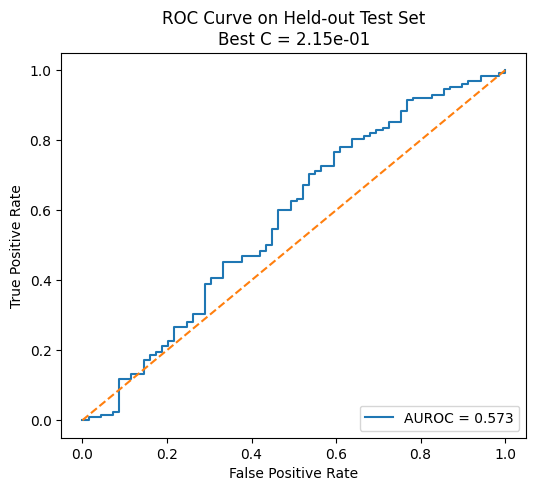

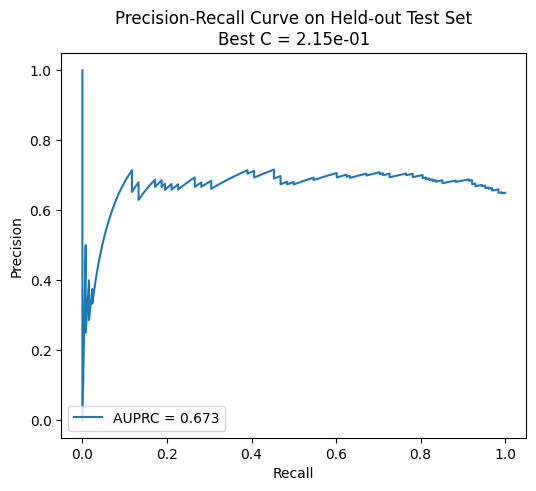

In [32]:
# === Step 31: Plot ROC and PR curves for best top-35k-elbow model ===

best_row_35k_elbow = results_df_35k_elbow.iloc[0]
best_C_35k_elbow = best_row_35k_elbow["C"]
best_model_35k_elbow = best_row_35k_elbow["model"]

print("Best C:", best_C_35k_elbow)
print("Best CV mean AUROC:", best_row_35k_elbow["cv_auc_mean"])
print("Held-out test AUROC:", best_row_35k_elbow["test_auc"])

# Predict probabilities on held-out test set
y_test_prob_35k_elbow = best_model_35k_elbow.predict_proba(X_test_35k_elbow)[:, 1]

# ---- ROC curve ----
fpr, tpr, _ = roc_curve(y_test, y_test_prob_35k_elbow)
test_auroc = roc_auc_score(y_test, y_test_prob_35k_elbow)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUROC = {test_auroc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve on Held-out Test Set\nBest C = {best_C_35k_elbow:.2e}")
plt.legend(loc="lower right")
plt.show()

# ---- PR curve ----
precision, recall, _ = precision_recall_curve(y_test, y_test_prob_35k_elbow)
test_auprc = average_precision_score(y_test, y_test_prob_35k_elbow)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"AUPRC = {test_auprc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve on Held-out Test Set\nBest C = {best_C_35k_elbow:.2e}")
plt.legend(loc="lower left")
plt.show()

In [33]:
# === Step 32: Save top-35k-elbow results ===

out_dir = "scanpy_hvg_results"
os.makedirs(out_dir, exist_ok=True)

results_df_35k_elbow.to_csv(
    os.path.join(out_dir, "results_35k_elbow.csv"),
    index=False
)

pd.DataFrame({
    "cpg_id": top_cpgs_35k_elbow
}).to_csv(
    os.path.join(out_dir, "top_cpgs_35k_elbow.csv"),
    index=False
)

print("Saved:")
print(os.path.join(out_dir, "results_35k_elbow.csv"))
print(os.path.join(out_dir, "top_cpgs_35k_elbow.csv"))

Saved:
scanpy_hvg_results/results_35k_elbow.csv
scanpy_hvg_results/top_cpgs_35k_elbow.csv


### results table

In [34]:
# === Step 33: Compare best results across all Scanpy subset strategies ===

summary_rows = [
    {
        "subset_strategy": "full_elbow",
        "n_cpgs": len(top_cpgs_full_elbow),
        "best_C": results_df_full_elbow.iloc[0]["C"],
        "cv_auc_mean": results_df_full_elbow.iloc[0]["cv_auc_mean"],
        "cv_auc_std": results_df_full_elbow.iloc[0]["cv_auc_std"],
        "train_auc": results_df_full_elbow.iloc[0]["train_auc"],
        "test_auc": results_df_full_elbow.iloc[0]["test_auc"],
        "test_auprc": results_df_full_elbow.iloc[0]["test_auprc"],
    },
    {
        "subset_strategy": "10k_elbow",
        "n_cpgs": len(top_cpgs_10k_elbow),
        "best_C": results_df_10k_elbow.iloc[0]["C"],
        "cv_auc_mean": results_df_10k_elbow.iloc[0]["cv_auc_mean"],
        "cv_auc_std": results_df_10k_elbow.iloc[0]["cv_auc_std"],
        "train_auc": results_df_10k_elbow.iloc[0]["train_auc"],
        "test_auc": results_df_10k_elbow.iloc[0]["test_auc"],
        "test_auprc": results_df_10k_elbow.iloc[0]["test_auprc"],
    },
    {
        "subset_strategy": "20k_elbow",
        "n_cpgs": len(top_cpgs_20k_elbow),
        "best_C": results_df_20k_elbow.iloc[0]["C"],
        "cv_auc_mean": results_df_20k_elbow.iloc[0]["cv_auc_mean"],
        "cv_auc_std": results_df_20k_elbow.iloc[0]["cv_auc_std"],
        "train_auc": results_df_20k_elbow.iloc[0]["train_auc"],
        "test_auc": results_df_20k_elbow.iloc[0]["test_auc"],
        "test_auprc": results_df_20k_elbow.iloc[0]["test_auprc"],
    },
    {
        "subset_strategy": "35k_elbow",
        "n_cpgs": len(top_cpgs_35k_elbow),
        "best_C": results_df_35k_elbow.iloc[0]["C"],
        "cv_auc_mean": results_df_35k_elbow.iloc[0]["cv_auc_mean"],
        "cv_auc_std": results_df_35k_elbow.iloc[0]["cv_auc_std"],
        "train_auc": results_df_35k_elbow.iloc[0]["train_auc"],
        "test_auc": results_df_35k_elbow.iloc[0]["test_auc"],
        "test_auprc": results_df_35k_elbow.iloc[0]["test_auprc"],
    },
    {
        "subset_strategy": "50k_elbow",
        "n_cpgs": len(top_cpgs_50k_elbow),
        "best_C": results_df_50k_elbow.iloc[0]["C"],
        "cv_auc_mean": results_df_50k_elbow.iloc[0]["cv_auc_mean"],
        "cv_auc_std": results_df_50k_elbow.iloc[0]["cv_auc_std"],
        "train_auc": results_df_50k_elbow.iloc[0]["train_auc"],
        "test_auc": results_df_50k_elbow.iloc[0]["test_auc"],
        "test_auprc": results_df_50k_elbow.iloc[0]["test_auprc"],
    },
]

summary_df = pd.DataFrame(summary_rows).sort_values(
    "cv_auc_mean", ascending=False
).reset_index(drop=True)

display(summary_df)

,subset_strategy,n_cpgs,best_C,cv_auc_mean,cv_auc_std,train_auc,test_auc,test_auprc
0,full_elbow,1770,2.154435,0.642383,0.020413,1.000000,0.662704,0.738913
1,10k_elbow,149,0.000464,0.564033,0.017292,0.733919,0.560122,0.706550
2,20k_elbow,387,0.000464,0.561526,0.043085,0.848511,0.580503,0.685390
3,35k_elbow,535,0.215443,0.548782,0.020073,0.998841,0.573030,0.672596
4,50k_elbow,535,0.215443,0.548782,0.020073,0.998841,0.573030,0.672596
